# SCNN + FHT (v1) — Proposed Method

Separable CNN on Fast Hilbert Transform envelope of sEMG windows (8×50). Full data, MPS accelerated.

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from config import MODELS_DIR, RANDOM_SEED, N_CLASSES, get_device
from src.data_splitter import (
    scenario_1_ideal,
    scenario_2_per_position,
    scenario_3_inter_subject,
    scenario_4_interday,
    scenario_5_fatigue,
)
from src.feature_extraction import fht_envelope_batch
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = get_device()
print(f"Device: {DEVICE}")

Device: mps


## Model definition — Separable CNN

In [2]:
class DepthwiseSeparableConv(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=1):
        super().__init__()
        self.depthwise = nn.Conv2d(in_ch, in_ch, kernel_size, padding=padding, groups=in_ch)
        self.pointwise = nn.Conv2d(in_ch, out_ch, kernel_size=1)

    def forward(self, x):
        return self.pointwise(self.depthwise(x))


class SeparableCNN(nn.Module):
    def __init__(self, n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            DepthwiseSeparableConv(1, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            DepthwiseSeparableConv(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


model = SeparableCNN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(f"SCNN Parameters: {n_params:,}")
print(f"CNN had:          101,831")
print(f"Reduction:        {101831 / n_params:.1f}×")

SCNN Parameters: 20,625
CNN had:          101,831
Reduction:        4.9×


## Training utilities

In [3]:
def apply_fht(X):
    return fht_envelope_batch(X)


def to_tensor(X, y):
    X_t = torch.from_numpy(X).float().unsqueeze(1)  # (N, 1, 8, 50)
    y_t = torch.from_numpy(y).long()
    return X_t, y_t


def make_loader(X, y, batch_size=256, shuffle=True):
    X_t, y_t = to_tensor(X, y)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)


def train_model(model, train_loader, n_epochs=30, lr=1e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)
    criterion = nn.CrossEntropyLoss()

    history = []
    for epoch in range(n_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        scheduler.step()
        epoch_loss = total_loss / total
        epoch_acc = correct / total
        history.append({"loss": epoch_loss, "acc": epoch_acc})
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} — loss: {epoch_loss:.4f}, acc: {epoch_acc:.4f}")
    return history


@torch.no_grad()
def predict(model, X):
    model.eval()
    X_t = torch.from_numpy(X).float().unsqueeze(1)
    loader = DataLoader(TensorDataset(X_t), batch_size=512, shuffle=False)
    preds = []
    for (xb,) in loader:
        xb = xb.to(DEVICE)
        preds.append(model(xb).argmax(1).cpu().numpy())
    return np.concatenate(preds)


def train_and_eval(X_train, y_train, X_test, y_test, title, n_epochs=30, lr=1e-3):
    # Apply FHT to both sets
    print("Applying FHT envelope...")
    X_train_fht = apply_fht(X_train)
    X_test_fht = apply_fht(X_test)
    print(f"FHT done. Train: {X_train_fht.shape}, Test: {X_test_fht.shape}")

    model = SeparableCNN().to(DEVICE)
    loader = make_loader(X_train_fht, y_train)
    history = train_model(model, loader, n_epochs=n_epochs, lr=lr)
    y_pred = predict(model, X_test_fht)
    metrics = print_report(y_test, y_pred, title=title)
    plot_confusion_matrix(y_test, y_pred, title=title)
    return model, history, metrics

---
## Scenario 1 — Ideal

In [4]:
X_train, y_train, X_test, y_test, info = scenario_1_ideal()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Loading windows: 100%|██████████| 251/251 [00:00<00:00, 1364.95it/s]


Train: (59159, 8, 50), Test: (29281, 8, 50)


Applying FHT envelope...
FHT done. Train: (59159, 8, 50), Test: (29281, 8, 50)
Epoch   1/30 — loss: 1.3547, acc: 0.4865
Epoch   5/30 — loss: 0.9606, acc: 0.6414
Epoch  10/30 — loss: 0.8624, acc: 0.6793
Epoch  15/30 — loss: 0.8055, acc: 0.6983
Epoch  20/30 — loss: 0.7764, acc: 0.7113
Epoch  25/30 — loss: 0.7479, acc: 0.7205
Epoch  30/30 — loss: 0.7373, acc: 0.7250

  SCNN+FHT — Scenario 1 (Ideal)
  Accuracy:  0.7180
  F1-macro:  0.7184
                    precision    recall  f1-score   support

              fist       0.88      0.82      0.85      4208
         open_hand       0.69      0.65      0.67      4179
  pinch_forefinger       0.60      0.62      0.61      4204
pinch_middlefinger       0.61      0.59      0.60      4239
               two       0.67      0.73      0.70      4175
          eversion       0.78      0.78      0.78      4064
             varus       0.81      0.84      0.82      4212

          accuracy                           0.72     29281
         macro avg 

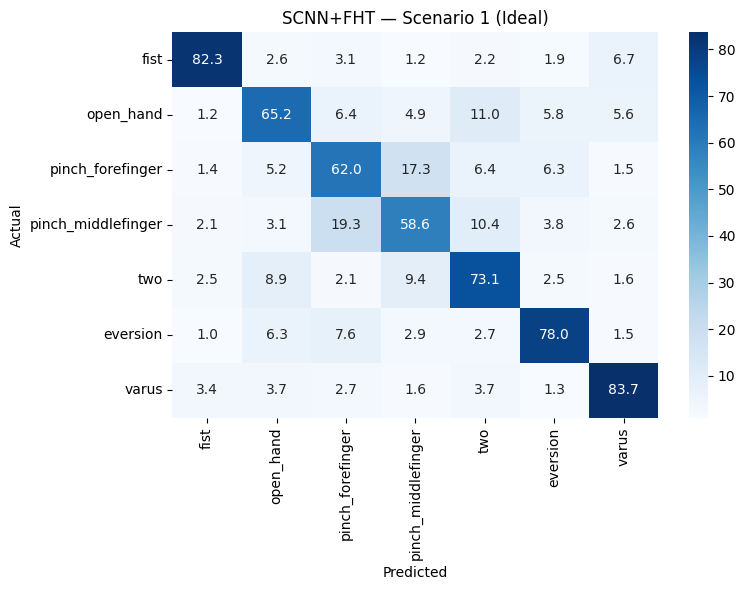

In [5]:
scnn_s1, hist_s1, metrics_s1 = train_and_eval(X_train, y_train, X_test, y_test, "SCNN+FHT — Scenario 1 (Ideal)")

In [6]:
# Per-subject SCNN evaluation (sanity check)
from src.data_splitter import load_metadata, load_windows_from_metadata, compute_normalization_stats, apply_normalization

meta = load_metadata()
subset = meta[(meta["session"] == 0) & (meta["position"] == 0)]

per_subject_acc = {}
for subj in sorted(subset["subject"].unique()):
    subj_df = subset[subset["subject"] == subj]
    train_df = subj_df[subj_df["repetition"].isin([0, 1])]
    test_df = subj_df[subj_df["repetition"] == 2]

    X_tr, y_tr = load_windows_from_metadata(train_df, verbose=False)
    X_te, y_te = load_windows_from_metadata(test_df, verbose=False)

    mean, std = compute_normalization_stats(X_tr)
    X_tr = apply_normalization(X_tr, mean, std)
    X_te = apply_normalization(X_te, mean, std)

    X_tr_fht = apply_fht(X_tr)
    X_te_fht = apply_fht(X_te)

    m = SeparableCNN().to(DEVICE)
    loader = make_loader(X_tr_fht, y_tr, batch_size=128)
    train_model(m, loader, n_epochs=30, lr=1e-3)
    y_pred = predict(m, X_te_fht)
    per_subject_acc[subj] = accuracy_score(y_te, y_pred)

accs = list(per_subject_acc.values())
print(f"Per-subject accuracy: mean={np.mean(accs):.4f}, min={np.min(accs):.4f}, max={np.max(accs):.4f}")
print()
for subj, acc in sorted(per_subject_acc.items()):
    bar = "█" * int(acc * 40)
    print(f"  {subj:4s}: {acc:.3f} {bar}")

Epoch   1/30 — loss: 1.8680, acc: 0.2960
Epoch   5/30 — loss: 0.7316, acc: 0.8418
Epoch  10/30 — loss: 0.2804, acc: 0.9148
Epoch  15/30 — loss: 0.2423, acc: 0.9167
Epoch  20/30 — loss: 0.2272, acc: 0.9180
Epoch  25/30 — loss: 0.2137, acc: 0.9270
Epoch  30/30 — loss: 0.2167, acc: 0.9186
Epoch   1/30 — loss: 1.8802, acc: 0.2526
Epoch   5/30 — loss: 1.2860, acc: 0.5777
Epoch  10/30 — loss: 0.6776, acc: 0.7625
Epoch  15/30 — loss: 0.5606, acc: 0.8080
Epoch  20/30 — loss: 0.5119, acc: 0.7952
Epoch  25/30 — loss: 0.4710, acc: 0.8359
Epoch  30/30 — loss: 0.4454, acc: 0.8343
Epoch   1/30 — loss: 1.7730, acc: 0.3875
Epoch   5/30 — loss: 0.6130, acc: 0.8039
Epoch  10/30 — loss: 0.2951, acc: 0.9049
Epoch  15/30 — loss: 0.2302, acc: 0.9252
Epoch  20/30 — loss: 0.1979, acc: 0.9384
Epoch  25/30 — loss: 0.1704, acc: 0.9443
Epoch  30/30 — loss: 0.1635, acc: 0.9489
Epoch   1/30 — loss: 1.8025, acc: 0.3303
Epoch   5/30 — loss: 0.6062, acc: 0.8555
Epoch  10/30 — loss: 0.2872, acc: 0.9146
Epoch  15/30 — l

In [7]:
torch.save(scnn_s1.state_dict(), MODELS_DIR / "scnn_s1_ideal.pt")
print("Saved.")

Saved.


---
## Scenario 2 — Electrode Shift (per-position curve)

In [8]:
X_train_s2, y_train_s2, test_by_pos, info_s2 = scenario_2_per_position()
print(f"Train: {X_train_s2.shape}")

print("Applying FHT to training data...")
X_train_s2_fht = apply_fht(X_train_s2)

Loading windows: 100%|██████████| 629/629 [00:00<00:00, 1484.00it/s]


Train: (71927, 8, 50)
Applying FHT to training data...


In [9]:
scnn_s2 = SeparableCNN().to(DEVICE)
loader_s2 = make_loader(X_train_s2_fht, y_train_s2)
hist_s2 = train_model(scnn_s2, loader_s2, n_epochs=30)

Epoch   1/30 — loss: 1.3060, acc: 0.5120
Epoch   5/30 — loss: 0.9392, acc: 0.6549
Epoch  10/30 — loss: 0.8393, acc: 0.6893
Epoch  15/30 — loss: 0.7829, acc: 0.7129
Epoch  20/30 — loss: 0.7533, acc: 0.7212
Epoch  25/30 — loss: 0.7341, acc: 0.7298
Epoch  30/30 — loss: 0.7233, acc: 0.7331


Position  1: acc = 0.3422
Position  2: acc = 0.2289
Position  3: acc = 0.2055
Position  4: acc = 0.1788
Position  5: acc = 0.1874
Position  6: acc = 0.2219
Position  7: acc = 0.3428
Position  8: acc = 0.4110
Position  9: acc = 0.1835
Position 10: acc = 0.1763


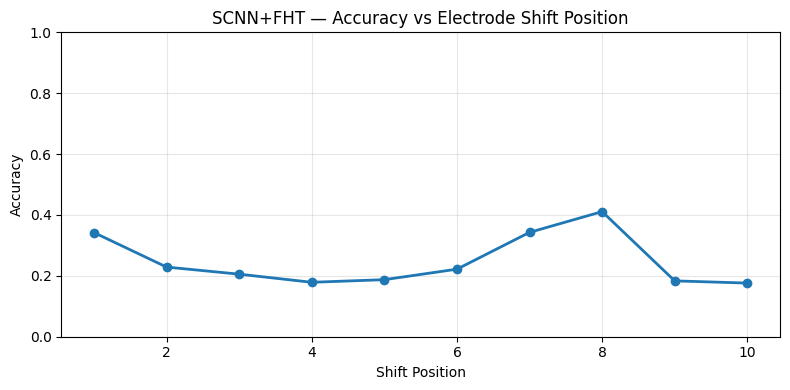

In [10]:
acc_per_pos = {}
for pos, (X_pos, y_pos) in sorted(test_by_pos.items()):
    X_pos_fht = apply_fht(X_pos)
    y_pred = predict(scnn_s2, X_pos_fht)
    acc_per_pos[pos] = accuracy_score(y_pos, y_pred)
    print(f"Position {pos:2d}: acc = {acc_per_pos[pos]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_pos.keys()), list(acc_per_pos.values()), "o-", linewidth=2)
plt.xlabel("Shift Position")
plt.ylabel("Accuracy")
plt.title("SCNN+FHT — Accuracy vs Electrode Shift Position")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "scnn_shift_curve.png"), dpi=150)
plt.show()

In [11]:
torch.save(scnn_s2.state_dict(), MODELS_DIR / "scnn_s2_shift.pt")
print("Saved.")

Saved.


---
## Scenario 3 — Inter-Subject

In [12]:
X_train_s3, y_train_s3, X_test_s3, y_test_s3, info_s3 = scenario_3_inter_subject()
print(f"Train: {X_train_s3.shape} ({len(info_s3['train_subjects'])} subjects)")
print(f"Test:  {X_test_s3.shape} ({info_s3['test_subjects']})")

Loading windows: 100%|██████████| 1385/1385 [00:01<00:00, 1355.41it/s]


Train: (618926, 8, 50) (24 subjects)
Test:  (168232, 8, 50) (['h7', 'h22', 'h3', 'h24', 'h16', 'h17'])


Applying FHT envelope...
FHT done. Train: (618926, 8, 50), Test: (168232, 8, 50)
Epoch   1/30 — loss: 1.4658, acc: 0.4342
Epoch   5/30 — loss: 1.2454, acc: 0.5274
Epoch  10/30 — loss: 1.1794, acc: 0.5554
Epoch  15/30 — loss: 1.1376, acc: 0.5720
Epoch  20/30 — loss: 1.1206, acc: 0.5796
Epoch  25/30 — loss: 1.1018, acc: 0.5867
Epoch  30/30 — loss: 1.0944, acc: 0.5903

  SCNN+FHT — Scenario 3 (Inter-Subject)
  Accuracy:  0.4851
  F1-macro:  0.4780
                    precision    recall  f1-score   support

              fist       0.48      0.50      0.49     23888
         open_hand       0.43      0.62      0.51     23933
  pinch_forefinger       0.39      0.30      0.34     24284
pinch_middlefinger       0.45      0.31      0.37     24064
               two       0.54      0.59      0.56     23897
          eversion       0.64      0.67      0.66     24069
             varus       0.45      0.41      0.43     24097

          accuracy                           0.49    168232
         

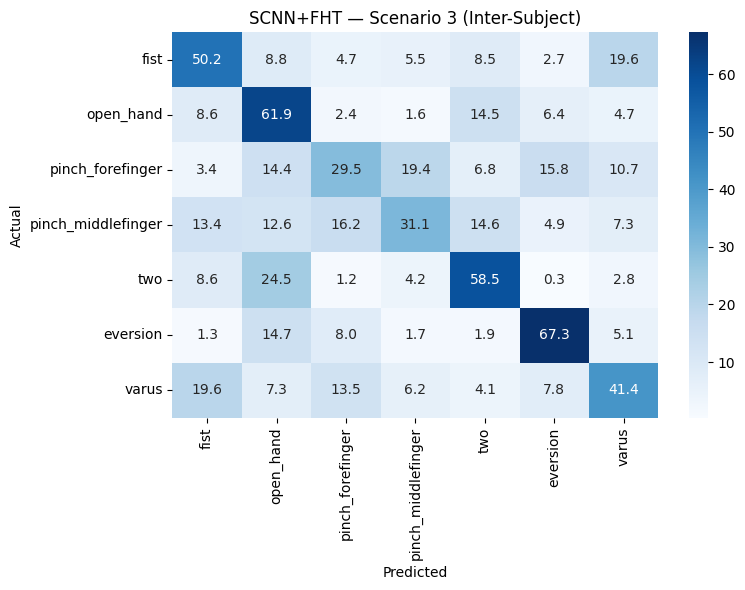

In [13]:
scnn_s3, hist_s3, metrics_s3 = train_and_eval(
    X_train_s3, y_train_s3, X_test_s3, y_test_s3,
    "SCNN+FHT — Scenario 3 (Inter-Subject)", n_epochs=30
)

In [14]:
torch.save(scnn_s3.state_dict(), MODELS_DIR / "scnn_s3_intersubject.pt")
print("Saved.")

Saved.


---
## Scenario 4 — Inter-Day

In [15]:
X_train_s4, y_train_s4, test_by_sess, info_s4 = scenario_4_interday()
print(f"Train: {X_train_s4.shape}")

X_train_s4_fht = apply_fht(X_train_s4)

Loading windows: 100%|██████████| 126/126 [00:00<00:00, 1553.87it/s]


Train: (13445, 8, 50)


In [16]:
scnn_s4 = SeparableCNN().to(DEVICE)
loader_s4 = make_loader(X_train_s4_fht, y_train_s4)
hist_s4 = train_model(scnn_s4, loader_s4, n_epochs=30)

Epoch   1/30 — loss: 1.6107, acc: 0.3915
Epoch   5/30 — loss: 0.7583, acc: 0.7213
Epoch  10/30 — loss: 0.5992, acc: 0.7763
Epoch  15/30 — loss: 0.5333, acc: 0.8007
Epoch  20/30 — loss: 0.4990, acc: 0.8148
Epoch  25/30 — loss: 0.4849, acc: 0.8195
Epoch  30/30 — loss: 0.4755, acc: 0.8228


Session 1: acc = 0.5638
Session 2: acc = 0.6848
Session 3: acc = 0.6605
Session 4: acc = 0.6953
Session 5: acc = 0.5754
Session 6: acc = 0.6717
Session 7: acc = 0.5926
Session 8: acc = 0.6730
Session 9: acc = 0.5342


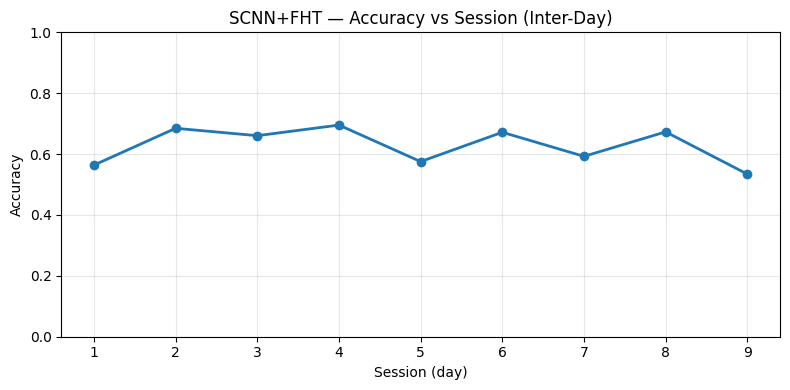

In [17]:
acc_per_sess = {}
for sess, (X_s, y_s) in sorted(test_by_sess.items()):
    X_s_fht = apply_fht(X_s)
    y_pred = predict(scnn_s4, X_s_fht)
    acc_per_sess[sess] = accuracy_score(y_s, y_pred)
    print(f"Session {sess}: acc = {acc_per_sess[sess]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_sess.keys()), list(acc_per_sess.values()), "o-", linewidth=2)
plt.xlabel("Session (day)")
plt.ylabel("Accuracy")
plt.title("SCNN+FHT — Accuracy vs Session (Inter-Day)")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "scnn_interday_curve.png"), dpi=150)
plt.show()

---
## Scenario 5 — Fatigue

In [18]:
X_train_s5, y_train_s5, test_by_fatigue, info_s5 = scenario_5_fatigue()
print(f"Train: {X_train_s5.shape}")

X_train_s5_fht = apply_fht(X_train_s5)

Loading windows: 100%|██████████| 252/252 [00:00<00:00, 1493.47it/s]


Train: (33046, 8, 50)


In [19]:
scnn_s5 = SeparableCNN().to(DEVICE)
loader_s5 = make_loader(X_train_s5_fht, y_train_s5)
hist_s5 = train_model(scnn_s5, loader_s5, n_epochs=30)

Epoch   1/30 — loss: 1.0804, acc: 0.6072
Epoch   5/30 — loss: 0.4673, acc: 0.8272
Epoch  10/30 — loss: 0.3963, acc: 0.8528
Epoch  15/30 — loss: 0.3601, acc: 0.8673
Epoch  20/30 — loss: 0.3424, acc: 0.8730
Epoch  25/30 — loss: 0.3261, acc: 0.8800
Epoch  30/30 — loss: 0.3188, acc: 0.8794


Position  2: acc = 0.8647
Position  3: acc = 0.8577
Position  4: acc = 0.8599
Position  5: acc = 0.8754
Position  6: acc = 0.8540
Position  7: acc = 0.8664
Position  8: acc = 0.8253
Position  9: acc = 0.8276
Position 10: acc = 0.8152


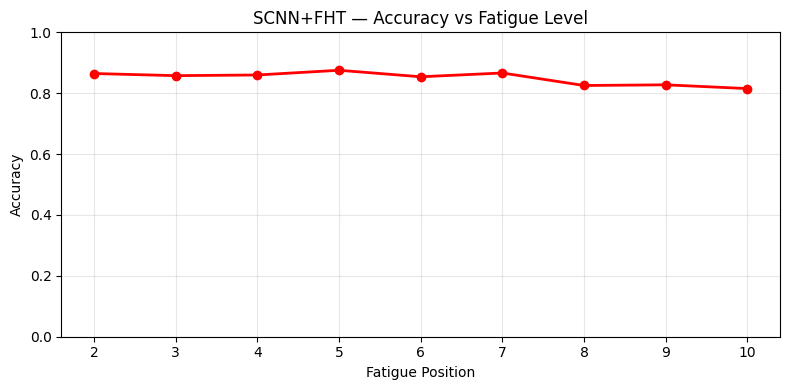

In [20]:
acc_per_fatigue = {}
for pos, (X_p, y_p) in sorted(test_by_fatigue.items()):
    X_p_fht = apply_fht(X_p)
    y_pred = predict(scnn_s5, X_p_fht)
    acc_per_fatigue[pos] = accuracy_score(y_p, y_pred)
    print(f"Position {pos:2d}: acc = {acc_per_fatigue[pos]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_fatigue.keys()), list(acc_per_fatigue.values()), "o-", linewidth=2, color="red")
plt.xlabel("Fatigue Position")
plt.ylabel("Accuracy")
plt.title("SCNN+FHT — Accuracy vs Fatigue Level")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "scnn_fatigue_curve.png"), dpi=150)
plt.show()

---
## Latency Measurement

In [21]:
scnn_s1.eval()
sample_raw = X_train[:1]  # raw window, not FHT yet

# Warm-up
sample_fht = torch.from_numpy(apply_fht(sample_raw)).float().unsqueeze(1).to(DEVICE)
for _ in range(10):
    _ = scnn_s1(sample_fht)
if DEVICE.type == "mps":
    torch.mps.synchronize()

def scnn_predict_single(x_raw):
    # Full pipeline: FHT + model inference
    x_fht = apply_fht(x_raw)
    x_t = torch.from_numpy(x_fht).float().unsqueeze(1).to(DEVICE)
    with torch.no_grad():
        out = scnn_s1(x_t)
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()

latency = measure_latency(scnn_predict_single, sample_raw, n_runs=500)
print_latency(latency, model_name="SCNN+FHT (FHT + inference)")
print(f"Parameters: {sum(p.numel() for p in scnn_s1.parameters()):,}")


Latency — SCNN+FHT (FHT + inference)
  Mean:   1.73 ms
  Median: 1.60 ms
  P95:    2.10 ms
  <300ms: ✓
Parameters: 20,625


---
## Summary

In [22]:
n_params = sum(p.numel() for p in scnn_s1.parameters())

print("\n" + "=" * 50)
print("SCNN+FHT (PROPOSED) — ALL SCENARIOS")
print("=" * 50)
print(f"S1 Ideal:         acc = {metrics_s1['accuracy']:.4f}, f1 = {metrics_s1['f1_macro']:.4f}")
print(f"S2 Shift (avg):   acc = {np.mean(list(acc_per_pos.values())):.4f}")
print(f"S3 Inter-subject: acc = {metrics_s3['accuracy']:.4f}, f1 = {metrics_s3['f1_macro']:.4f}")
print(f"S4 Inter-day (avg): acc = {np.mean(list(acc_per_sess.values())):.4f}")
print(f"S5 Fatigue (avg): acc = {np.mean(list(acc_per_fatigue.values())):.4f}")
print(f"Latency (p95):    {latency['p95_ms']:.2f} ms")
print(f"Parameters:       {n_params:,}")
print("=" * 50)

print("\n\n--- COMPARISON TABLE ---")
print(f"{'Metric':<22} {'SVM':>10} {'CNN':>10} {'SCNN+FHT':>10}")
print("-" * 55)
print(f"{'S1 Ideal':<22} {'65.19%':>10} {'75.78%':>10} {metrics_s1['accuracy']*100:>9.2f}%")
print(f"{'S2 Shift (avg)':<22} {'23.99%':>10} {'26.41%':>10} {np.mean(list(acc_per_pos.values()))*100:>9.2f}%")
print(f"{'S3 Inter-subject':<22} {'40.27%':>10} {'52.90%':>10} {metrics_s3['accuracy']*100:>9.2f}%")
print(f"{'S4 Inter-day (avg)':<22} {'63.03%':>10} {'67.30%':>10} {np.mean(list(acc_per_sess.values()))*100:>9.2f}%")
print(f"{'S5 Fatigue (avg)':<22} {'81.20%':>10} {'86.98%':>10} {np.mean(list(acc_per_fatigue.values()))*100:>9.2f}%")
print(f"{'Latency p95 (ms)':<22} {'5.40':>10} {'1.74':>10} {latency['p95_ms']:>9.2f}")
print(f"{'Parameters':<22} {'—':>10} {'101,831':>10} {n_params:>10,}")


SCNN+FHT (PROPOSED) — ALL SCENARIOS
S1 Ideal:         acc = 0.7180, f1 = 0.7184
S2 Shift (avg):   acc = 0.2478
S3 Inter-subject: acc = 0.4851, f1 = 0.4780
S4 Inter-day (avg): acc = 0.6279
S5 Fatigue (avg): acc = 0.8496
Latency (p95):    2.10 ms
Parameters:       20,625


--- COMPARISON TABLE ---
Metric                        SVM        CNN   SCNN+FHT
-------------------------------------------------------
S1 Ideal                   65.19%     75.78%     71.80%
S2 Shift (avg)             23.99%     26.41%     24.78%
S3 Inter-subject           40.27%     52.90%     48.51%
S4 Inter-day (avg)         63.03%     67.30%     62.79%
S5 Fatigue (avg)           81.20%     86.98%     84.96%
Latency p95 (ms)             5.40       1.74      2.10
Parameters                      —    101,831     20,625
